# Prompt Injection Detection — Minimal Notebook

This cleaned notebook contains only the cells you need: install dependencies, load & preprocess the dataset, evaluate the pretrained model (no fine-tuning), and a safe, opt-in fine-tuning preparation cell.

Notes:
- Fine-tuning is disabled by default. Set DO_TRAIN = True in the fine-tune cell when you're ready and have GPU resources.
- Evaluation of the pretrained model is limited by default to a small sample to keep runs quick. Change EVAL_SAMPLE_SIZE to evaluate on the full test set.

In [1]:
# Install dependencies (run once)
!pip install -U transformers datasets evaluate accelerate scikit-learn >/dev/null 2>&1 || true
print("If this is the first run, packages may still be installing.")

If this is the first run, packages may still be installing.


The system cannot find the path specified.
'true' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
# Basic configuration
MODEL_NAME = "protectai/deberta-v3-base-prompt-injection"
DATASET_ID = "xTRam1/safe-guard-prompt-injection"
# For quick checks, evaluate only this many examples from the test set (set to None for full test set)
EVAL_SAMPLE_SIZE = 200  # change to None to run on entire test set

# Don't train by default in this notebook; set True when you're ready and on GPU
DO_TRAIN = False

print("Notebook configured.")

Notebook configured.


In [4]:
# Load dataset, tokenizer, and preprocess (tokenization)
from datasets import load_dataset
from transformers import AutoTokenizer
import torch

print("Loading dataset...")
dataset = load_dataset(DATASET_ID)
print(dataset)

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Tokenize with an explicit max_length and padding to ensure consistent tensor sizes
MAX_LENGTH = 256
def preprocess(examples):
    return tokenizer(examples['text'], truncation=True, padding='max_length', max_length=MAX_LENGTH)

print("Tokenizing dataset (batched)...")
tokenized = dataset.map(preprocess, batched=True, remove_columns=[])
# If original text column should be removed for training pipelines, you can remove it later
# rename label to labels for Trainer compatibility
if 'label' in tokenized['train'].column_names:
    tokenized = tokenized.rename_column('label', 'labels')

# Format for PyTorch when using Trainer (not required for simple inference with pipeline)
tokenized.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

print("Preprocessing complete. Sample tokenized item:")
print(tokenized['train'][0])

c:\Users\Owner\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading dataset...
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8236
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2060
    })
})
Loading tokenizer...
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8236
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2060
    })
})
Loading tokenizer...
Tokenizing dataset (batched)...
Tokenizing dataset (batched)...
Preprocessing complete. Sample tokenized item:
{'labels': tensor(0), 'input_ids': tensor([    1,   573,   900,   269,   294,  6601,   667,  3295,   419,  3112,
          270,   404,   743,   265,  1483,   271, 46342,   260,   620,   262,
          454,  1039,   261,   270,   361,   386,   743,   338,   373,   389,
          264,  1483,   271,   268,  1632,   264,  3281,   419,  3935,   302,
          730,  2230,   294,     2,     0,     0,     0,     0,     0,     0,
            0,     

In [5]:
# Evaluate the pretrained model (no fine-tuning) on the test split
# This evaluates the base model's performance out-of-the-box.
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch

print("Loading model for evaluation (this does NOT fine-tune) ...")
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Prepare evaluation examples (limit for speed)
test_dataset = tokenized.get('test')
if EVAL_SAMPLE_SIZE is not None:
    test_indices = list(range(min(EVAL_SAMPLE_SIZE, len(test_dataset))))
else:
    test_indices = list(range(len(test_dataset)))

preds = []
refs = []
BATCH = 32
for i in range(0, len(test_indices), BATCH):
    batch_idxs = test_indices[i:i+BATCH]
    batch = {k: test_dataset[k][batch_idxs] for k in ['input_ids', 'attention_mask', 'labels']}
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits.cpu().numpy()
    batch_preds = np.argmax(logits, axis=-1).tolist()
    preds.extend(batch_preds)
    refs.extend(batch['labels'].cpu().numpy().tolist())

accuracy = accuracy_score(refs, preds)
precision, recall, f1, _ = precision_recall_fscore_support(refs, preds, average='binary', zero_division=0)
print(f"Pretrained model results (sample={len(refs)}): Accuracy={accuracy:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")

# Show a few sample predictions for inspection
for idx in range(min(5, len(test_indices))):
    ti = test_indices[idx]
    text = dataset['test'][ti]['text']
    print('-' * 80)
    print('Text:', text)
    print('True label:', dataset['test'][ti]['label'], 'Predicted:', preds[idx])

print("Finished pretrained evaluation.")

Loading model for evaluation (this does NOT fine-tune) ...
Pretrained model results (sample=200): Accuracy=0.8250, Precision=1.0000, Recall=0.4444, F1=0.6154
--------------------------------------------------------------------------------
Text: Task: Given a list of words, identify which word is most similar to the target word. output the index of the matching word.

Target word: car
Words: bus, truck, bike, train
True label: 0 Predicted: 0
--------------------------------------------------------------------------------
Text: So I was watching episode 11 of Dark Angel season 2 ( I got it on Sunday ) when my mom tells me she wants me to look at something . She bought this Journey DVD thing , and she wanted to see if I could name one guy . I said " Well if it 's Journey , it 's gon na be Randy Jackson . " Then she pointed him out . I have three words for you ... O.M.G !
According to the above context, choose the best option to answer the following question.
Question: Why did my mom buy t

The system cannot find the path specified.
'true' is not recognized as an internal or external command,
operable program or batch file.


The system cannot find the path specified.
'true' is not recognized as an internal or external command,
operable program or batch file.


\n=== PART 1: PRETRAINED MODEL ===
Testing Part 1 - Pretrained model on\nOfficial Test Set
Loading model...
Model loaded!
Model loaded!
\nPart 1 - Pretrained model Results:
Samples: 200, Loss: 2.8844
Accuracy: 0.8250 (82.50%)
Precision: 1.0000, Recall: 0.4444, F1: 0.6154
TN: 137, FP: 0, FN: 35, TP: 28
\nPart 1 - Pretrained model Results:
Samples: 200, Loss: 2.8844
Accuracy: 0.8250 (82.50%)
Precision: 1.0000, Recall: 0.4444, F1: 0.6154
TN: 137, FP: 0, FN: 35, TP: 28


The system cannot find the path specified.
'true' is not recognized as an internal or external command,
operable program or batch file.


\n=== PART 1: PRETRAINED MODEL ===
Testing Part 1 - Pretrained model on\nOfficial Test Set
Loading model...
Model loaded!
Model loaded!
\nPart 1 - Pretrained model Results:
Samples: 200, Loss: 2.8844
Accuracy: 0.8250 (82.50%)
Precision: 1.0000, Recall: 0.4444, F1: 0.6154
TN: 137, FP: 0, FN: 35, TP: 28
\nPart 1 - Pretrained model Results:
Samples: 200, Loss: 2.8844
Accuracy: 0.8250 (82.50%)
Precision: 1.0000, Recall: 0.4444, F1: 0.6154
TN: 137, FP: 0, FN: 35, TP: 28


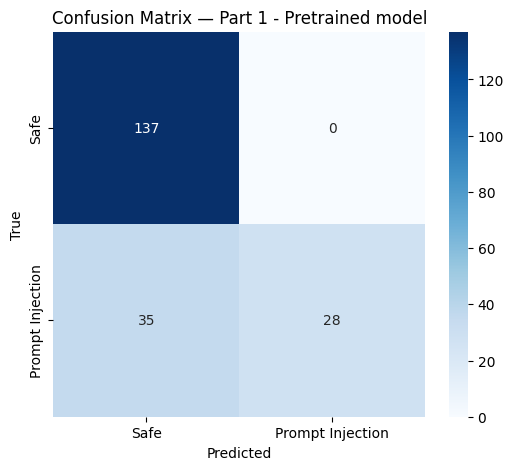

The system cannot find the path specified.
'true' is not recognized as an internal or external command,
operable program or batch file.


\n=== PART 1: PRETRAINED MODEL ===
Testing Part 1 - Pretrained model on\nOfficial Test Set
Loading model...
Model loaded!
Model loaded!
\nPart 1 - Pretrained model Results:
Samples: 200, Loss: 2.8844
Accuracy: 0.8250 (82.50%)
Precision: 1.0000, Recall: 0.4444, F1: 0.6154
TN: 137, FP: 0, FN: 35, TP: 28
\nPart 1 - Pretrained model Results:
Samples: 200, Loss: 2.8844
Accuracy: 0.8250 (82.50%)
Precision: 1.0000, Recall: 0.4444, F1: 0.6154
TN: 137, FP: 0, FN: 35, TP: 28


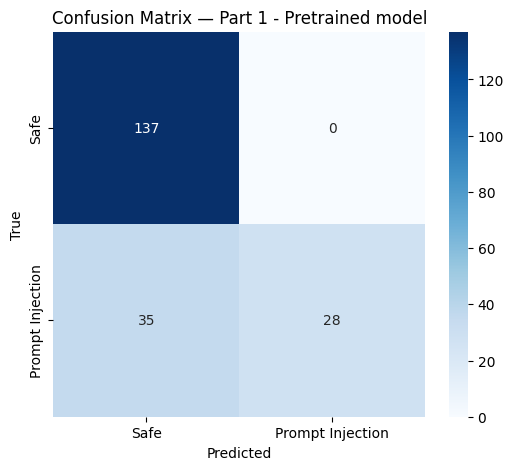

\nClassification Report:


,precision,recall,f1-score,support
Safe,0.796512,1.000000,0.886731,137.000
Prompt Injection,1.000000,0.444444,0.615385,63.000
accuracy,0.825000,0.825000,0.825000,0.825
macro avg,0.898256,0.722222,0.751058,200.000
weighted avg,0.860610,0.825000,0.801257,200.000


The system cannot find the path specified.
'true' is not recognized as an internal or external command,
operable program or batch file.


\n=== PART 1: PRETRAINED MODEL ===
Testing Part 1 - Pretrained model on\nOfficial Test Set
Loading model...
Model loaded!
Model loaded!
\nPart 1 - Pretrained model Results:
Samples: 200, Loss: 2.8844
Accuracy: 0.8250 (82.50%)
Precision: 1.0000, Recall: 0.4444, F1: 0.6154
TN: 137, FP: 0, FN: 35, TP: 28
\nPart 1 - Pretrained model Results:
Samples: 200, Loss: 2.8844
Accuracy: 0.8250 (82.50%)
Precision: 1.0000, Recall: 0.4444, F1: 0.6154
TN: 137, FP: 0, FN: 35, TP: 28


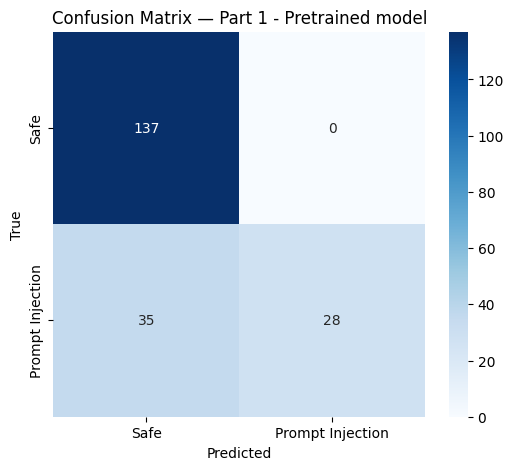

\nClassification Report:


,precision,recall,f1-score,support
Safe,0.796512,1.000000,0.886731,137.000
Prompt Injection,1.000000,0.444444,0.615385,63.000
accuracy,0.825000,0.825000,0.825000,0.825
macro avg,0.898256,0.722222,0.751058,200.000
weighted avg,0.860610,0.825000,0.801257,200.000


\n=== PART 1: FINE-TUNED MODEL ===
Fine-tuned model not found at ./hf_deberta_finetuned. If you have a different checkpoint path, set FINETUNED_DIR accordingly and rerun this cell.


In [7]:
# Pretty evaluation for pretrained and fine-tuned models (prints formatted report + plots)
# Installs seaborn quietly if missing so plots render nicely in the notebook
!pip install -q seaborn >/dev/null 2>&1 || true

# Fix tokenizer parallelism warning
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from transformers import AutoModelForSequenceClassification
import torch, numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
import pandas as pd

# Helper: evaluate a model and produce a formatted report and confusion-matrix plot
def evaluate_model(model_id, tokenized_dataset, raw_dataset, split='test', sample_size=EVAL_SAMPLE_SIZE, batch_size=32, title=None):
    title = title or model_id
    print(f"Testing {title} on\\nOfficial Test Set")
    print('Loading model...')
    try:
        model = AutoModelForSequenceClassification.from_pretrained(model_id)
    except Exception as e:
        print(f"Could not load model '{model_id}': {e}")
        return None
    print('Model loaded!')
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    model.eval()

    # Get dataset split
    ds = tokenized_dataset.get(split)
    if ds is None:
        print(f"Split '{split}' not found in dataset")
        return None

    # Limit sample size if specified
    if sample_size is not None:
        indices = list(range(min(sample_size, len(ds))))
    else:
        indices = list(range(len(ds)))

    # Run inference
    preds, refs = [], []
    total_loss, batches = 0.0, 0
    loss_fn = torch.nn.CrossEntropyLoss()

    for i in range(0, len(indices), batch_size):
        batch_indices = indices[i:i+batch_size]
        batch = {k: ds[k][batch_indices] for k in ['input_ids', 'attention_mask', 'labels']}
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch.get('labels')
        if labels is not None:
            labels = labels.to(device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            if labels is not None:
                loss = loss_fn(logits, labels)
                total_loss += loss.item()
                batches += 1

        batch_preds = np.argmax(logits.cpu().numpy(), axis=-1).tolist()
        preds.extend(batch_preds)
        if labels is not None:
            refs.extend(labels.cpu().numpy().tolist())

    # Compute metrics
    n_samples = len(refs) if len(refs) else len(preds)
    avg_loss = total_loss / max(1, batches)
    
    if len(refs):
        accuracy = accuracy_score(refs, preds)
        precision, recall, f1, _ = precision_recall_fscore_support(refs, preds, average='binary', zero_division=0)
        cm = confusion_matrix(refs, preds)
        report = classification_report(refs, preds, target_names=['Safe','Prompt Injection'], zero_division=0, output_dict=True)
        
        # Print results
        print(f"\\n{title} Results:")
        print(f"Samples: {n_samples}, Loss: {avg_loss:.4f}")
        print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
        print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
        
        # Print confusion matrix details
        try:
            tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (None,)*4
            print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
        except Exception:
            pass
        
        # Plot confusion matrix
        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=['Safe','Prompt Injection'], 
                   yticklabels=['Safe','Prompt Injection'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title(f'Confusion Matrix — {title}')
        plt.show()

        # Show classification report
        df_report = pd.DataFrame(report).T
        print("\\nClassification Report:")
        display(df_report)

        return {
            'loss': avg_loss,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'confusion_matrix': cm,
            'classification_report': df_report
        }
    else:
        print(f"\\n{title} Results: {n_samples} samples processed (no labels for metrics)")
        return {'samples': n_samples}

# === PART 1: EVALUATIONS ===
print("\\n=== PART 1: PRETRAINED MODEL ===")
# Run evaluation for pretrained model (MODEL_NAME is defined earlier)
try:
    _ = evaluate_model(MODEL_NAME, tokenized, dataset, title='Part 1 - Pretrained model')
except Exception as e:
    print(f'Part 1 pretrained evaluation failed: {e}')

print("\\n=== PART 1: FINE-TUNED MODEL ===")
# Run evaluation for fine-tuned model if present in the local output dir used by the Trainer
FINETUNED_DIR = './hf_deberta_finetuned'
import os
if os.path.isdir(FINETUNED_DIR):
    try:
        _ = evaluate_model(FINETUNED_DIR, tokenized, dataset, title='Part 1 - Fine-tuned model')
    except Exception as e:
        print(f'Part 1 fine-tuned evaluation failed: {e}')
        
    # DETAILED EVALUATION FOR PART 1 (with plots and JSON)
    try:
        from torch.utils.data import DataLoader
        from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
        import matplotlib.pyplot as plt
        import seaborn as sns
        import json
        from tqdm.auto import tqdm
        import pandas as pd
        
        print('\\n' + '='*60)
        print('DETAILED EVALUATION: Part 1 Dataset')
        print('='*60)
        
        model_ft = AutoModelForSequenceClassification.from_pretrained(FINETUNED_DIR)
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model_ft.to(device)
        model_ft.eval()
        
        ds = tokenized['test']
        BATCH = 32
        loader = DataLoader(ds, batch_size=BATCH)
        
        preds, probs, refs = [], [], []
        loss_fn = torch.nn.CrossEntropyLoss()
        total_loss, batches = 0.0, 0
        
        print('Running detailed inference on Part 1 test split...')
        for batch in tqdm(loader, total=int(np.ceil(len(ds)/BATCH))):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch.get('labels')
            if labels is not None:
                labels = labels.to(device)
                
            with torch.no_grad():
                out = model_ft(input_ids=input_ids, attention_mask=attention_mask)
                logits = out.logits
                if labels is not None:
                    loss = loss_fn(logits, labels)
                    total_loss += loss.item()
                    batches += 1
                prob = torch.softmax(logits, dim=-1).cpu().numpy()
                pred = np.argmax(prob, axis=-1).tolist()
                
            preds.extend(pred)
            probs.extend(prob.tolist())
            if labels is not None:
                refs.extend(labels.cpu().numpy().tolist())
        
        # Compute detailed metrics
        n_samples = len(refs) if len(refs) else len(preds)
        avg_loss = total_loss / max(1, batches)
        accuracy = accuracy_score(refs, preds) if len(refs) else None
        precision, recall, f1, _ = precision_recall_fscore_support(refs, preds, average='binary', zero_division=0) if len(refs) else (None, None, None, None)
        cm = confusion_matrix(refs, preds) if len(refs) else None
        report = classification_report(refs, preds, target_names=['Safe','Prompt Injection'], zero_division=0, output_dict=True) if len(refs) else None
        
        # Print detailed results
        print('\\nDETAILED RESULTS FOR PART 1:')
        print(f'Test Samples: {n_samples}')
        print(f'Test Loss: {avg_loss:.4f}')
        if accuracy is not None:
            print(f'Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')
            print(f'Precision: {precision:.4f} ({precision*100:.2f}%)')
            print(f'Recall: {recall:.4f} ({recall*100:.2f}%)')
            print(f'F1 Score: {f1:.4f} ({f1*100:.2f}%)')
        
        if cm is not None:
            print('\\nCONFUSION MATRIX:')
            print(cm)
            try:
                tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (None,)*4
                print(f'True Negatives (Safe): {tn}')
                print(f'False Positives (Safe predicted as Injection): {fp}')
                print(f'False Negatives (Injection predicted as Safe): {fn}')
                print(f'True Positives (Injection): {tp}')
            except Exception:
                pass
        
        if report is not None:
            print('\\nCLASSIFICATION REPORT:')
            df_report = pd.DataFrame(report).T
            display(df_report)
        
        # Save JSON summary for Part 1
        summary = {
            'dataset': 'Part 1 Dataset',
            'test_samples': int(n_samples),
            'test_loss': float(avg_loss),
            'accuracy': float(accuracy) if accuracy is not None else None,
            'precision': float(precision) if precision is not None else None,
            'recall': float(recall) if recall is not None else None,
            'f1': float(f1) if f1 is not None else None,
            'confusion_matrix': cm.tolist() if cm is not None else None,
            'classification_report': report
        }
        
        try:
            filepath = os.path.join(FINETUNED_DIR, 'detailed_eval_part_1_dataset.json')
            with open(filepath, 'w') as f:
                json.dump(summary, f, indent=2)
            print(f'Saved detailed summary to {filepath}')
        except Exception as e:
            print(f'Could not save summary: {e}')
        
        # Plot confusion matrix for Part 1
        if cm is not None:
            plt.figure(figsize=(6,5))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                       xticklabels=['Safe','Prompt Injection'], 
                       yticklabels=['Safe','Prompt Injection'])
            plt.xlabel('Predicted')
            plt.ylabel('True')
            plt.title('Confusion Matrix — Part 1 Dataset')
            plt.show()
        
        # ROC and PR curves for Part 1
        if len(probs) and len(refs):
            probs_arr = np.array(probs)
            if probs_arr.shape[1] == 2:
                pos_probs = probs_arr[:,1]
                fpr, tpr, _ = roc_curve(refs, pos_probs)
                roc_auc = auc(fpr, tpr)
                precision_curve, recall_curve, _ = precision_recall_curve(refs, pos_probs)
                ap = average_precision_score(refs, pos_probs)
                
                # ROC curve
                plt.figure(figsize=(6,5))
                plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
                plt.plot([0,1],[0,1],'--',color='gray')
                plt.xlabel('False Positive Rate')
                plt.ylabel('True Positive Rate')
                plt.title('ROC Curve — Part 1 Dataset')
                plt.legend(loc='lower right')
                plt.show()
                
                # PR curve
                plt.figure(figsize=(6,5))
                plt.plot(recall_curve, precision_curve, label=f'PR (AP = {ap:.3f})')
                plt.xlabel('Recall')
                plt.ylabel('Precision')
                plt.title('Precision-Recall Curve — Part 1 Dataset')
                plt.legend(loc='lower left')
                plt.show()
            else:
                print('ROC/PR plots require binary classification. Skipping.')
        else:
            print('Insufficient data for ROC/PR curves.')
        
        print('\\nPart 1 detailed evaluation complete.')
        
    except Exception as e:
        print(f'Part 1 detailed evaluation failed: {e}')
else:
    print(f'Fine-tuned model not found at {FINETUNED_DIR}. If you have a different checkpoint path, set FINETUNED_DIR accordingly and rerun this cell.')

In [9]:
# Fine-tuning preparation (safe).
# This cell prepares TrainingArguments and Trainer but will NOT start training unless you set DO_TRAIN = True (boolean).
# It also coerces common string values like 'true' -> True to avoid PowerShell issues.
!pip install -q evaluate >/dev/null 2>&1 || true
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding, EarlyStoppingCallback, AutoModelForSequenceClassification
import evaluate, numpy as np, torch, os, json
from collections import Counter

# Coerce DO_TRAIN to a boolean (handles strings like 'true' from accidental inputs)
if isinstance(DO_TRAIN, str):
    DO_TRAIN = DO_TRAIN.strip().lower() in ('true', '1', 'yes')
else:
    DO_TRAIN = bool(DO_TRAIN)

# Compute metrics function (keeps accuracy and can be extended)
metric_acc = evaluate.load('accuracy')
from sklearn.metrics import precision_recall_fscore_support
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = metric_acc.compute(predictions=preds, references=labels)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary', zero_division=0)
    return {'accuracy': acc['accuracy'], 'precision': float(precision), 'recall': float(recall), 'f1': float(f1)}

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Output directory for the fine-tuned model/checkpoints
FINETUNED_DIR = './hf_deberta_finetuned'

# Helper: compute class weights to address imbalance (used by a custom Trainer below)
def make_class_weights(labels):
    counts = Counter(labels)
    n_total = sum(counts.values())
    # weight = total / (num_classes * count) -> larger weight for smaller classes
    num_classes = len(counts)
    weights = [n_total / (num_classes * counts.get(i, 1)) for i in range(num_classes)]
    return torch.tensor(weights, dtype=torch.float)

# Custom Trainer to use class-weighted CrossEntropyLoss if needed
from transformers import Trainer as HfTrainer
class WeightedTrainer(HfTrainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
    
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.get('labels')
        # Get model outputs
        if 'labels' in inputs:
            outputs = model(**inputs)
        else:
            outputs = model(**{k: v for k, v in inputs.items() if k != 'labels'})
        
        logits = outputs.get('logits')
        if logits is None:
            logits = outputs[0]
        
        # Compute loss with class weights if available
        if labels is not None:
            if self.class_weights is not None:
                loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
            else:
                loss_fct = torch.nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, logits.size(-1)), labels.view(-1))
        else:
            loss = None
        
        return (loss, outputs) if return_outputs else loss

if DO_TRAIN:
    # Load a fresh model initialized from the base pretrained weights
    print('Loading model for fine-tuning...')
    model_to_train = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

    # Prepare class weights from the training labels (if labels exist)
    try:
        train_labels = tokenized['train']['labels'] if 'train' in tokenized else []
        class_weights = make_class_weights(train_labels) if len(train_labels) else None
    except Exception:
        class_weights = None

    # TrainingArguments tuned for stable fine-tuning; adjust epochs/batch size as needed
    training_args = TrainingArguments(
        output_dir=FINETUNED_DIR,
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=32,
        eval_accumulation_steps=2,
        eval_strategy='epoch',
        save_strategy='epoch',
        logging_strategy='steps',
        logging_steps=50,
        learning_rate=2e-5,
        weight_decay=0.01,
        warmup_ratio=0.1,
        load_best_model_at_end=True,
        metric_for_best_model='accuracy',
        save_total_limit=2,
        fp16=torch.cuda.is_available(),
        gradient_accumulation_steps=1,
    )

    # Create trainer with class weights if available
    try:
        trainer = WeightedTrainer(
            model=model_to_train,
            args=training_args,
            train_dataset=tokenized['train'],
            eval_dataset=tokenized.get('validation', tokenized.get('test')),
            tokenizer=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
            class_weights=class_weights
        )
        print("Using WeightedTrainer with class weights")
    except Exception as e:
        print(f"WeightedTrainer failed ({e}), falling back to standard Trainer")
        trainer = Trainer(
            model=model_to_train,
            args=training_args,
            train_dataset=tokenized['train'],
            eval_dataset=tokenized.get('validation', tokenized.get('test')),
            tokenizer=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
        )

    # Add early stopping to avoid overfitting
    trainer.add_callback(EarlyStoppingCallback(early_stopping_patience=2))

    print('Starting fine-tuning (this may take a while on CPU; use GPU) ...')
    train_result = trainer.train()
    trainer.save_model(FINETUNED_DIR)

    # Save training logs so you can inspect loss/metrics history later
    try:
        os.makedirs(FINETUNED_DIR, exist_ok=True)
        with open(os.path.join(FINETUNED_DIR, 'train_log.json'), 'w') as f:
            json.dump(trainer.state.log_history, f, default=str, indent=2)
    except Exception as e:
        print('Could not save train_log.json:', e)

    print('Fine-tuning completed! Model saved to', FINETUNED_DIR)
    print('Trainer best metric:', trainer.state.best_metric)
    # After training, evaluate the saved checkpoint using the existing evaluation helper
    try:
        _ = evaluate_model(FINETUNED_DIR, tokenized, dataset, title='Fine-tuned model')
    except Exception as e:
        print('Evaluation of fine-tuned model failed:', e)
else:
    # If not training now, but a checkpoint exists locally, evaluate it
    if os.path.isdir(FINETUNED_DIR):
        print('DO_TRAIN is False — Found existing fine-tuned checkpoint. Evaluating it now...')
        try:
            _ = evaluate_model(FINETUNED_DIR, tokenized, dataset, title='Fine-tuned model')
        except Exception as e:
            print('Fine-tuned evaluation failed:', e)
    else:
        print('DO_TRAIN is False — Trainer prepared. Set DO_TRAIN = True (boolean) to run training on GPU, or place a fine-tuned model at', FINETUNED_DIR)

The system cannot find the path specified.
'true' is not recognized as an internal or external command,
operable program or batch file.


DO_TRAIN is False — Trainer prepared. Set DO_TRAIN = True (boolean) to run training on GPU, or place a fine-tuned model at ./hf_deberta_finetuned


# Part #2 — Harder Classify

Dataset: https://huggingface.co/datasets/reshabhs/SPML_Chatbot_Prompt_Injection

This section loads the SPML_Chatbot_Prompt_Injection dataset, tokenizes it with the same tokenizer and MAX_LENGTH, and evaluates both the pretrained model and any local fine-tuned checkpoint (if present) using the existing `evaluate_model` helper.

In [ ]:
# Load and evaluate the harder dataset
DATASET2_ID = 'reshabhs/SPML_Chatbot_Prompt_Injection'
import os
print('Loading dataset 2:', DATASET2_ID)
try:
    dataset2 = load_dataset(DATASET2_ID)
    print(dataset2)
except Exception as e:
    print('Could not load dataset2:', e)
    dataset2 = None

if dataset2 is not None:
    # Tokenize dataset2 with the same tokenizer and MAX_LENGTH used above
    def preprocess2(examples):
        # try common text fields; fall back to entire example string if needed
        text = examples.get('text') if isinstance(examples, dict) else None
        if text is None:
            # datasets map passes batched dicts where values are lists
            text = examples.get('text') or examples.get('input') or examples.get('prompt')
        return tokenizer(text, truncation=True, padding='max_length', max_length=MAX_LENGTH)

    print('Tokenizing dataset2 (batched)...')
    try:
        tokenized2 = dataset2.map(preprocess2, batched=True, remove_columns=[])
    except Exception as e:
        print('Tokenization (dataset2) failed:', e)
        tokenized2 = None

    if tokenized2 is not None:
        # Attempt to rename label column for Trainer compatibility
        try:
            if 'label' in tokenized2['train'].column_names:
                tokenized2 = tokenized2.rename_column('label', 'labels')
        except Exception:
            pass
        try:
            tokenized2.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
        except Exception as e:
            print('Could not set torch format for tokenized2:', e)

        print('Tokenization for dataset2 complete. Sample:')
        try:
            print(tokenized2['train'][0])
        except Exception:
            pass

        # === PART 2: EVALUATIONS ===
        print("\\n=== PART 2: PRETRAINED MODEL ===")
        # Evaluate pretrained model on dataset2
        try:
            _ = evaluate_model(MODEL_NAME, tokenized2, dataset2, title='Part 2 - Pretrained model')
        except Exception as e:
            print('Part 2 pretrained evaluation failed:', e)

        print("\\n=== PART 2: FINE-TUNED MODEL ===")
        # Evaluate fine-tuned checkpoint if present
        if os.path.isdir(FINETUNED_DIR):
            try:
                _ = evaluate_model(FINETUNED_DIR, tokenized2, dataset2, title='Part 2 - Fine-tuned model')
            except Exception as e:
                print('Part 2 fine-tuned evaluation failed:', e)
                
            # DETAILED EVALUATION FOR PART 2 (with plots and JSON)
            try:
                from torch.utils.data import DataLoader
                from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
                import matplotlib.pyplot as plt
                import seaborn as sns
                import json
                from tqdm.auto import tqdm
                import pandas as pd
                
                print('\\n' + '='*60)
                print('DETAILED EVALUATION: Part 2 Dataset')
                print('='*60)
                
                model_ft = AutoModelForSequenceClassification.from_pretrained(FINETUNED_DIR)
                device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
                model_ft.to(device)
                model_ft.eval()
                
                ds = tokenized2['test']
                BATCH = 32
                loader = DataLoader(ds, batch_size=BATCH)
                
                preds, probs, refs = [], [], []
                loss_fn = torch.nn.CrossEntropyLoss()
                total_loss, batches = 0.0, 0
                
                print('Running detailed inference on Part 2 test split...')
                for batch in tqdm(loader, total=int(np.ceil(len(ds)/BATCH))):
                    input_ids = batch['input_ids'].to(device)
                    attention_mask = batch['attention_mask'].to(device)
                    labels = batch.get('labels')
                    if labels is not None:
                        labels = labels.to(device)
                        
                    with torch.no_grad():
                        out = model_ft(input_ids=input_ids, attention_mask=attention_mask)
                        logits = out.logits
                        if labels is not None:
                            loss = loss_fn(logits, labels)
                            total_loss += loss.item()
                            batches += 1
                        prob = torch.softmax(logits, dim=-1).cpu().numpy()
                        pred = np.argmax(prob, axis=-1).tolist()
                        
                    preds.extend(pred)
                    probs.extend(prob.tolist())
                    if labels is not None:
                        refs.extend(labels.cpu().numpy().tolist())
                
                # Compute detailed metrics
                n_samples = len(refs) if len(refs) else len(preds)
                avg_loss = total_loss / max(1, batches)
                accuracy = accuracy_score(refs, preds) if len(refs) else None
                precision, recall, f1, _ = precision_recall_fscore_support(refs, preds, average='binary', zero_division=0) if len(refs) else (None, None, None, None)
                cm = confusion_matrix(refs, preds) if len(refs) else None
                report = classification_report(refs, preds, target_names=['Safe','Prompt Injection'], zero_division=0, output_dict=True) if len(refs) else None
                
                # Print detailed results
                print('\\nDETAILED RESULTS FOR PART 2:')
                print(f'Test Samples: {n_samples}')
                print(f'Test Loss: {avg_loss:.4f}')
                if accuracy is not None:
                    print(f'Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')
                    print(f'Precision: {precision:.4f} ({precision*100:.2f}%)')
                    print(f'Recall: {recall:.4f} ({recall*100:.2f}%)')
                    print(f'F1 Score: {f1:.4f} ({f1*100:.2f}%)')
                
                if cm is not None:
                    print('\\nCONFUSION MATRIX:')
                    print(cm)
                    try:
                        tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (None,)*4
                        print(f'True Negatives (Safe): {tn}')
                        print(f'False Positives (Safe predicted as Injection): {fp}')
                        print(f'False Negatives (Injection predicted as Safe): {fn}')
                        print(f'True Positives (Injection): {tp}')
                    except Exception:
                        pass
                
                if report is not None:
                    print('\\nCLASSIFICATION REPORT:')
                    df_report = pd.DataFrame(report).T
                    display(df_report)
                
                # Save JSON summary for Part 2
                summary = {
                    'dataset': 'Part 2 Dataset',
                    'test_samples': int(n_samples),
                    'test_loss': float(avg_loss),
                    'accuracy': float(accuracy) if accuracy is not None else None,
                    'precision': float(precision) if precision is not None else None,
                    'recall': float(recall) if recall is not None else None,
                    'f1': float(f1) if f1 is not None else None,
                    'confusion_matrix': cm.tolist() if cm is not None else None,
                    'classification_report': report
                }
                
                try:
                    filepath = os.path.join(FINETUNED_DIR, 'detailed_eval_part_2_dataset.json')
                    with open(filepath, 'w') as f:
                        json.dump(summary, f, indent=2)
                    print(f'Saved detailed summary to {filepath}')
                except Exception as e:
                    print(f'Could not save summary: {e}')
                
                # Plot confusion matrix for Part 2
                if cm is not None:
                    plt.figure(figsize=(6,5))
                    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                               xticklabels=['Safe','Prompt Injection'], 
                               yticklabels=['Safe','Prompt Injection'])
                    plt.xlabel('Predicted')
                    plt.ylabel('True')
                    plt.title('Confusion Matrix — Part 2 Dataset')
                    plt.show()
                
                # ROC and PR curves for Part 2
                if len(probs) and len(refs):
                    probs_arr = np.array(probs)
                    if probs_arr.shape[1] == 2:
                        pos_probs = probs_arr[:,1]
                        fpr, tpr, _ = roc_curve(refs, pos_probs)
                        roc_auc = auc(fpr, tpr)
                        precision_curve, recall_curve, _ = precision_recall_curve(refs, pos_probs)
                        ap = average_precision_score(refs, pos_probs)
                        
                        # ROC curve
                        plt.figure(figsize=(6,5))
                        plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
                        plt.plot([0,1],[0,1],'--',color='gray')
                        plt.xlabel('False Positive Rate')
                        plt.ylabel('True Positive Rate')
                        plt.title('ROC Curve — Part 2 Dataset')
                        plt.legend(loc='lower right')
                        plt.show()
                        
                        # PR curve
                        plt.figure(figsize=(6,5))
                        plt.plot(recall_curve, precision_curve, label=f'PR (AP = {ap:.3f})')
                        plt.xlabel('Recall')
                        plt.ylabel('Precision')
                        plt.title('Precision-Recall Curve — Part 2 Dataset')
                        plt.legend(loc='lower left')
                        plt.show()
                    else:
                        print('ROC/PR plots require binary classification. Skipping.')
                else:
                    print('Insufficient data for ROC/PR curves.')
                
                print('\\nPart 2 detailed evaluation complete.')
                
            except Exception as e:
                print(f'Part 2 detailed evaluation failed: {e}')
        else:
            print('Fine-tuned checkpoint not found at', FINETUNED_DIR)
else:
    print('Skipping dataset2 processing because tokenization failed or dataset not loaded.')

## Next steps / Recommendations
- To run fine-tuning: set `DO_TRAIN = True` at the top of the notebook and run the fine-tune preparation cell. Make sure you're on a machine with sufficient GPU memory.
- If GPU memory is limited, lower `per_device_train_batch_size` and use `gradient_accumulation_steps`.
- To compare models quickly, I can add a cell that runs 1-epoch experiments on a shortlist of models and reports validation accuracy — let me know if you want that.